In [3]:
import os
import re
import math
import shutil
import subprocess

from datetime import datetime, timedelta, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.dates import DateFormatter
from dateutil.tz import tzutc, tzlocal
from scipy import stats
from scipy.optimize import brentq, curve_fit, fsolve, least_squares



import sys
import signal
import tempfile
import time
from collections import Counter
from IPython.display import clear_output

In [4]:
%load_ext autoreload
%autoreload 2

import official_GSSHA_Python_functions as gf

%load_ext autoreload
%autoreload 2

import official_GSSHA_Python_post_process_functions as gppf

cwd = os.getcwd()
script_dir = Path.cwd() 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# SET UP INPUTS FOR MODEL CALIBRATION AND STAGE MAPS

In [5]:
GSSHA_prj_name = "Waialua_FIM_testing"
#name of model files

model_dir = script_dir / GSSHA_prj_name
#model directory where all txt files are stored to run with executables

GSSHA_executables = script_dir / 'GSSHA_applications'
#executable files for GSSHA in windows

test_input_flow_results_dir = model_dir / "TEST_INPUT_FLOW_SIMULATIONS"
#place where we store initial model runs to set up calibration

Gauge_Datum_offset = 13.835
#offset between LMSL and gauge recordings

Min_flood_stage = 26 
#minor flood stage from NWS (of 1-2 feet lower if you prefer)

Max_flood_stage = 38
#max recorded gauge level or NWS major reported stage (or 1-3 feet over if you have ample computer time, a couple feet higher is better for calibration)

# Set up first calibration

In [6]:
#SET UP CALIBRATION FROM INITIAL INPUT FLOWS

# Once Offset is determined, set up model paramters for running stage height maps
gage_readings = np.arange(Min_flood_stage, Max_flood_stage, 1).tolist()

#Set up the storage of results
modeling_set_test_results= {"gauge_readings_ft":[],
                            "expected_WSE_m":[],
                            "expected_WSE_ft":[],  
                            "convergence_time": [], 
                            "input_flows":[]}

#Fill in some metadata about gauge readings, expected model outputs to figure out the rest
expected_model_outputs = [x - Gauge_Datum_offset for x in gage_readings]
modeling_set_test_results["gauge_readings_ft"] = gage_readings
modeling_set_test_results["expected_WSE_ft"] = expected_model_outputs
modeling_set_test_results["expected_WSE_m"]  = [round(ft * 0.3048, 2) for ft in expected_model_outputs]

# First determine input flows needed for modeling water surface elevations


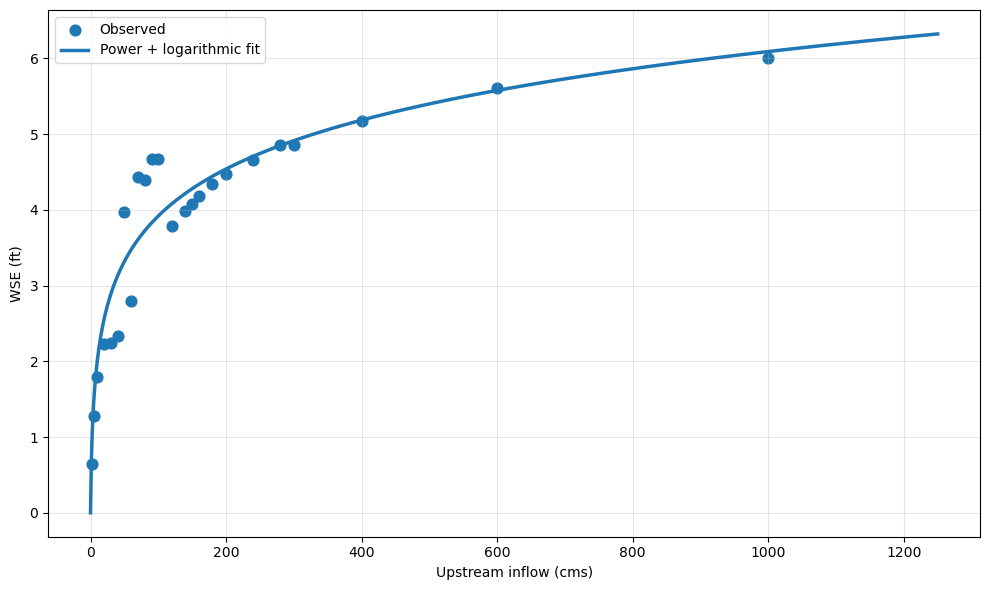

In [9]:
modeling_set_test_results["input_flows"] = gppf.get_input_flows_for_gauge_stages(
    modeling_results_directory = test_input_flow_results_dir,
    requested_WSE =  modeling_set_test_results["expected_WSE_m"],
    plot=True,
)

# Read the test flow .dep output to decide on a low flow boundary time and a high flow boundary time to ensure model reaches convergence

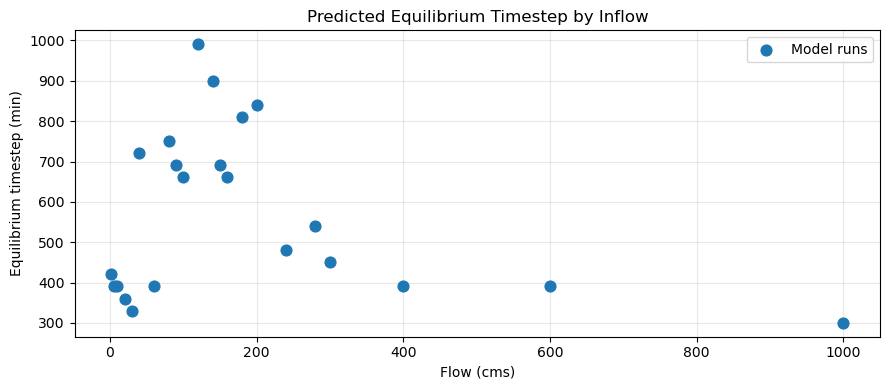

In [11]:
gppf.view_timestep_convergence(model_results_directory = test_input_flow_results_dir, area_change_threshold = 1000, number_timesteps_below_threshold = 6)

## Define model simulation time and incorporate to model storage

In [12]:
medium_flow_threshold = 400
high_flow_threshold = 1000

low_flow_timing = 1000
medium_flow_timing = 420
high_flow_timing = 330


modeling_set_test_results["convergence_time"] = gppf.predict_timestep_convergence(
    modeling_set_test_results["input_flows"],
    medium_flow_threshold,
    high_flow_threshold,
    low_flow_timing,
    medium_flow_timing,
    high_flow_timing,
)

In [13]:
modeling_set_test_results

{'gauge_readings_ft': [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37],
 'expected_WSE_m': [3.71,
  4.01,
  4.32,
  4.62,
  4.93,
  5.23,
  5.54,
  5.84,
  6.15,
  6.45,
  6.76,
  7.06],
 'expected_WSE_ft': [12.165,
  13.165,
  14.165,
  15.165,
  16.165,
  17.165,
  18.165,
  19.165,
  20.165,
  21.165,
  22.165,
  23.165],
 'convergence_time': [1000,
  1000,
  1000,
  1000,
  1000,
  420,
  420,
  420,
  330,
  330,
  330,
  330],
 'input_flows': [78.79853761383335,
  110.94372633220347,
  157.0683620312199,
  218.58860248211727,
  305.5755328157096,
  419.7375944719896,
  578.3230676694398,
  782.5216833713446,
  1060.4482774357823,
  1410.7228117912987,
  1876.9150300172712,
  2451.1406264440147]}

# NOT NECESSARY!

# Expected Gauge Discharge for each stage

In [451]:
def cumulative_to_instantaneous(
    df,
    cumulative_column="cumulative_discharge",
    time_column="timestep_min",
    output_column="instantaneous_discharge",
):
    """
    Convert cumulative volume (m³) to instantaneous discharge (m³/s).

    Parameters
    ----------
    df : pandas.DataFrame
    cumulative_column : str
        Column containing cumulative volume (m³).
    time_column : str
        Column containing timestep in minutes.
    output_column : str
        Name of the output discharge column.

    Returns
    -------
    pandas.DataFrame
    """
    df = df.copy()

    dV = df[cumulative_column].diff()
    dt = df[time_column].diff() * 60.0  # minutes -> seconds

    df[output_column] = dV / dt

    # Set the first value to NaN since there is no previous timestep
    df.loc[df.index[0], output_column] = float("nan")

    return df

def read_GSSHA_oqc(filepath):
    """
    Read a GSSHA .oqc file.

    Returns
    -------
    pandas.DataFrame
        Columns:
        - timestep_min
        - discharge
        - cumulative_discharge
    """
    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        header=None,
        names=["timestep_min", "cumulative_discharge"],
    )

    return df

In [452]:
oqc_file_paths = gppf.get_flow_file_dict(
    test_input_flow_results_dir,
    ".oqc"
)

oqc_file_read = {}

for flow_cms, filepath in oqc_file_paths.items():
    oqc = gppf.read_GSSHA_oqc(filepath)

    oqc_file_read[flow_cms] = oqc

oqc_stable_discharge = {} #max discharge recorded at gauge

for flow_cms, df in oqc_file_read.items():
    # Calculate instantaneous discharge
    df = gppf.cumulative_to_instantaneous(df)

    # Save the updated DataFrame back to the dictionary
    oqc_file_read[flow_cms] = df

    # Average of the last 60 minutes
    oqc_stable_discharge[flow_cms] = (
        df["instantaneous_discharge"].max()
    )

oqc_stable_discharge

{2: 2.0923255833333316,
 5: 5.0121341333331655,
 10: 10.281410483333941,
 20: 20.364340033333338,
 30: 37.184196799999945,
 40: 59.187880866666575,
 50: 57.69205544999956,
 60: 117.37468998333401,
 70: 126.57581978333182,
 80: 118.83621589999724,
 90: 125.65741604999639,
 100: 132.63401753332775,
 120: 120.03779111667536,
 140: 140.04501174999945,
 150: 150.1118653833323,
 160: 160.11887226666633,
 180: 180.03902856665664,
 200: 199.4107577833347,
 240: 237.5805146333451,
 280: 279.974880833334,
 300: 293.61371873334673,
 400: 359.0223395000018,
 600: 419.0443884833347,
 1000: 450.6751306166669}

In [453]:

def asymptotic_saturation_fit(
    q_inflow,
    q_max,
    k,
):
    """
    Gauge-discharge saturation curve:

        Q_gauge = Q_max * (1 - exp(-k * Q_inflow))
    """
    q_inflow = np.asarray(q_inflow, dtype=float)

    return q_max * (
        1.0 - np.exp(-k * q_inflow)
    )


def fit_gauge_discharge_model(
    stable_discharge_dict,
    initial_guess=None,
):
    q_inflow = np.array(
        sorted(stable_discharge_dict.keys()),
        dtype=float,
    )

    q_gauge = np.array(
        [
            stable_discharge_dict[q]
            for q in q_inflow
        ],
        dtype=float,
    )

    if initial_guess is None:
        initial_guess = (
            q_gauge.max() * 1.1,
            0.0025,
        )

    parameters, covariance = curve_fit(
        asymptotic_saturation_fit,
        q_inflow,
        q_gauge,
        p0=initial_guess,
        bounds=(
            [0.0, 0.0],
            [np.inf, np.inf],
        ),
        maxfev=50000,
    )

    q_max, k = parameters

    q_gauge_predicted = asymptotic_saturation_fit(
        q_inflow,
        q_max,
        k,
    )

    residuals = (
        q_gauge - q_gauge_predicted
    )

    ss_res = np.sum(residuals**2)

    ss_tot = np.sum(
        (q_gauge - q_gauge.mean())**2
    )

    r_squared = 1.0 - ss_res / ss_tot

    rmse = np.sqrt(
        np.mean(residuals**2)
    )

    return {
        "model_type": "asymptotic_saturation",
        "equation": (
            "Q_gauge = Q_max * "
            "(1 - exp(-k * Q_inflow))"
        ),
        "parameters": {
            "q_max": float(q_max),
            "k": float(k),
        },
        "covariance": covariance,
        "r_squared": float(r_squared),
        "rmse": float(rmse),
        "q_inflow": q_inflow,
        "q_gauge_observed": q_gauge,
        "q_gauge_predicted": q_gauge_predicted,
        "residuals": residuals,
        "source_data": stable_discharge_dict.copy(),
    }


def predict_gauge_discharge(
    q_inflow,
    gauge_discharge_model,
):
    parameters = gauge_discharge_model["parameters"]

    return asymptotic_saturation_fit(
        q_inflow,
        parameters["q_max"],
        parameters["k"],
    )


def plot_gauge_discharge_model(
    gauge_discharge_model,
    q_plot_max=None,
):
    q_inflow = gauge_discharge_model["q_inflow"]

    q_gauge = (
        gauge_discharge_model[
            "q_gauge_observed"
        ]
    )

    q_max = (
        gauge_discharge_model[
            "parameters"
        ]["q_max"]
    )

    k = (
        gauge_discharge_model[
            "parameters"
        ]["k"]
    )

    if q_plot_max is None:
        q_plot_max = q_inflow.max() * 1.25

    q_smooth = np.linspace(
        0,
        q_plot_max,
        1000,
    )

    q_predict = asymptotic_saturation_fit(
        q_smooth,
        q_max,
        k,
    )

    plt.figure(figsize=(8, 6))

    plt.scatter(
        q_inflow,
        q_gauge,
        s=60,
        label="Model results",
        zorder=3,
    )

    plt.plot(
        q_smooth,
        q_predict,
        linewidth=2.5,
        label="Asymptotic saturation curve",
    )

    plt.plot(
        [0, q_plot_max],
        [0, q_plot_max],
        "k--",
        linewidth=1.5,
        label="1:1 line",
    )

    plt.xlabel("Upstream inflow (cms)")
    plt.ylabel("Gauge discharge (cms)")
    plt.title(
        "Upstream Inflow–Gauge Discharge Relationship"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        "Q_gauge = "
        f"{q_max:.6f} * "
        f"(1 - exp(-{k:.8f} * Q_inflow))"
    )

    print(f"Q_max = {q_max:.6f} cms")
    print(f"k = {k:.8f}")
    print(
        f"R² = "
        f"{gauge_discharge_model['r_squared']:.6f}"
    )
    print(
        f"RMSE = "
        f"{gauge_discharge_model['rmse']:.6f} cms"
    )

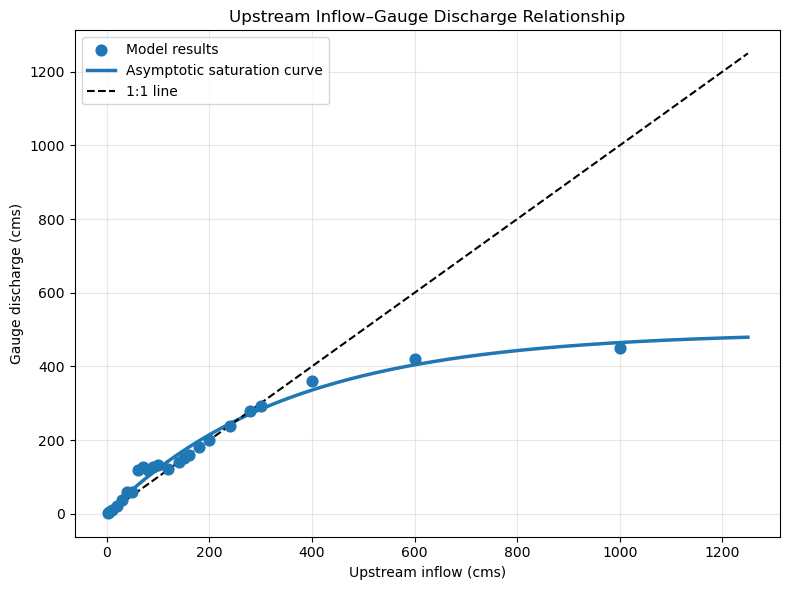

Q_gauge = 493.166593 * (1 - exp(-0.00285402 * Q_inflow))
Q_max = 493.166593 cms
k = 0.00285402
R² = 0.979714
RMSE = 17.603226 cms


In [454]:
gauge_discharge_model = fit_gauge_discharge_model(
    oqc_stable_discharge
)

plot_gauge_discharge_model(
    gauge_discharge_model
)

In [455]:
modeling_set_test_results["expected_gauge_discharge_cms"] = [
    round(discharge, 2)
    for discharge in predict_gauge_discharge(
        modeling_set_test_results["input_flows"],
        gauge_discharge_model,
    )
]

print(modeling_set_test_results["expected_gauge_discharge_cms"])

[99.32, 133.85, 178.17, 228.89, 286.99, 344.32, 398.51, 440.31, 469.26, 484.37, 490.84, 492.71]


# Save model test results to use in final model simulation

In [456]:
df = pd.DataFrame(modeling_set_test_results)
df.to_csv(test_input_flow_results_dir / (str(offset) + "modeling_test_results.csv"), index=False)


print(f"Saved to:\n{test_input_flow_results_dir /(str(offset) + "modeling_test_results.csv")}")

Saved to:
C:\Users\bgorberg\Documents\GitHub\Flood_Stage_Maps\RUN_GSSHA\Waialua_FIM_testing\TEST_INPUT_FLOW_SIMULATIONS\13.835modeling_test_results.csv
